In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
import joblib
import json
from config.paths import config
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [19]:
class WeightedAverageEnsemble:
    def __init__(self, models, weights):
        self.models = models
        self.weights = weights

    def fit(self, X, y):
        for model in self.models:
            model.fit(X, y)
        return self

    def predict_proba(self, X):
        probas = [model.predict_proba(X) for model in self.models]
        return np.average(probas, axis=0, weights=self.weights)

    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba[:, 1] > 0.5).astype(int)

final_package = joblib.load(config.models_dir / "final_deployment_model.pkl")
processed_data = joblib.load(config.processed_data_dir / "feature_engineered_data.pkl")

model = final_package['model']
feature_names = final_package['feature_names']
X_train = processed_data['X_train']
X_test = processed_data['X_test']
y_train = processed_data['y_train']
y_test = processed_data['y_test']

print(f"Model: {final_package['model_name']}")
print(f"Features: {len(feature_names)}")
print(f"Test set shape: {X_test.shape}")

Model: LightGBM
Features: 102
Test set shape: (39040, 102)


100%|██████████| 100/100 [03:23<00:00,  2.04s/it]


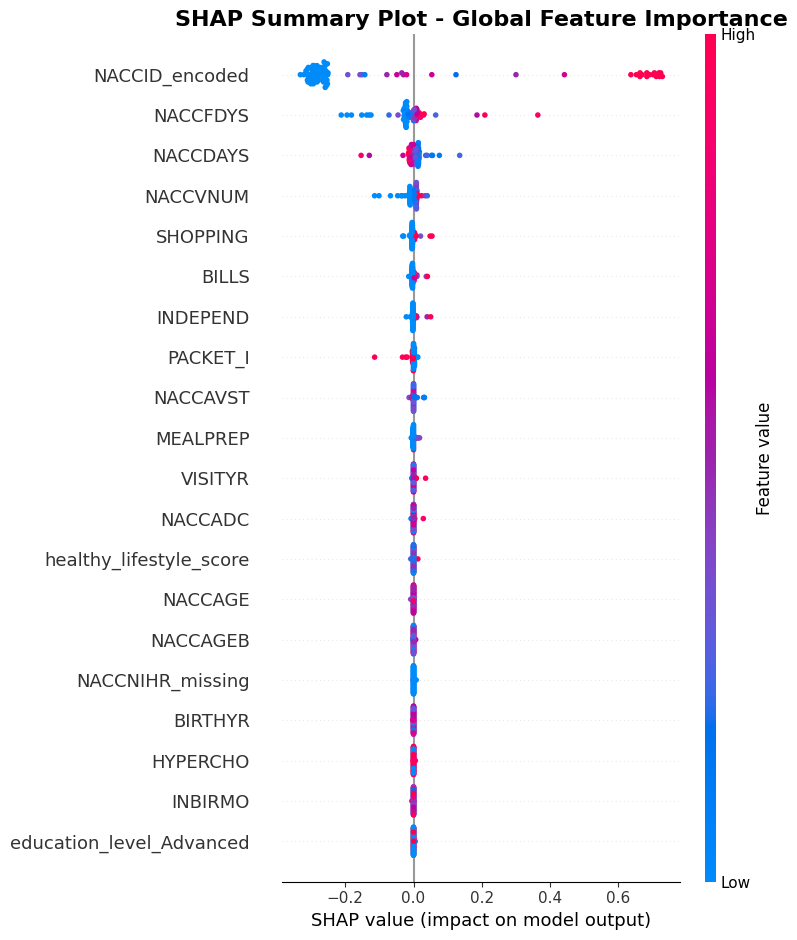

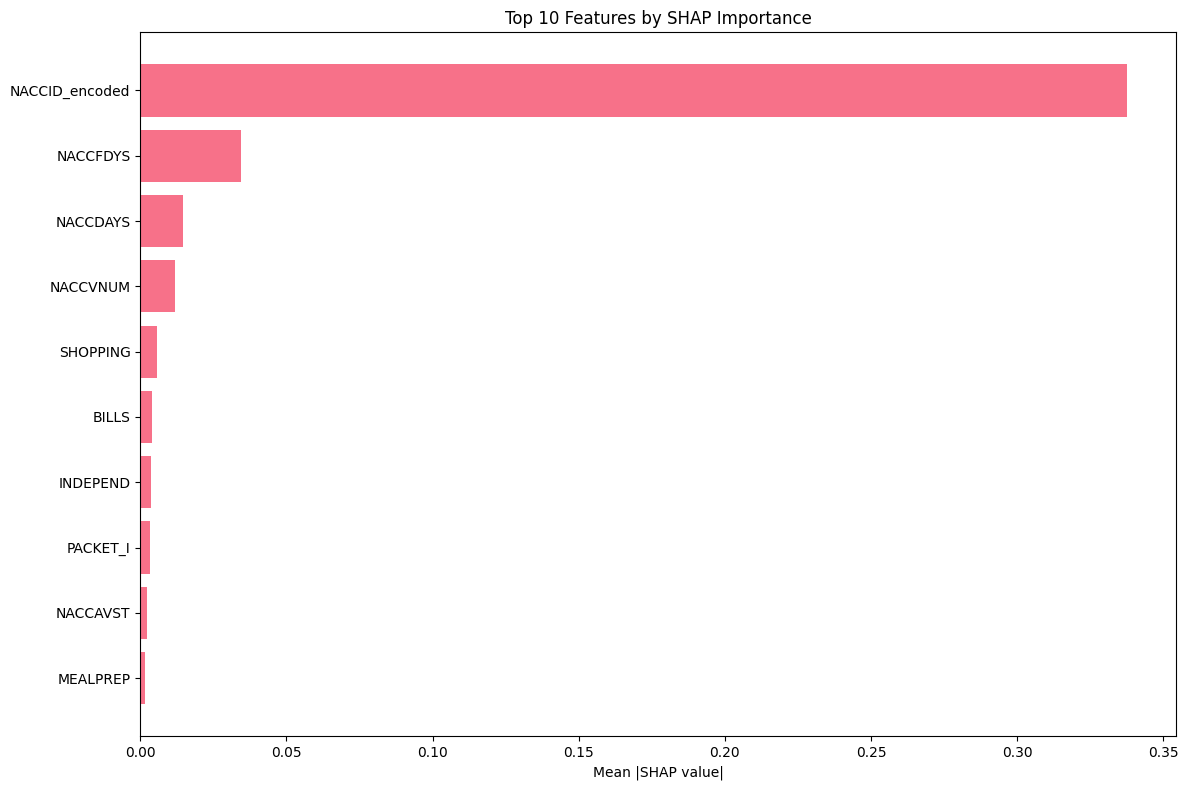

In [26]:
explainer = shap.KernelExplainer(model.predict_proba, X_train.iloc[:100])
shap_values = explainer.shap_values(X_test.iloc[:100])

plt.figure(figsize=(15, 10))
shap.summary_plot(shap_values[:, :, 1], X_test.iloc[:100], feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot - Global Feature Importance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(config.reports_dir / 'shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

shap_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values[:, :, 1]).mean(0)
}).sort_values('mean_abs_shap', ascending=False)

top_10_shap = shap_df.head(10)
plt.figure(figsize=(12, 8))
plt.barh(top_10_shap['feature'], top_10_shap['mean_abs_shap'])
plt.xlabel('Mean |SHAP value|')
plt.title('Top 10 Features by SHAP Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(config.reports_dir / 'top_10_shap_features.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1000x600 with 0 Axes>

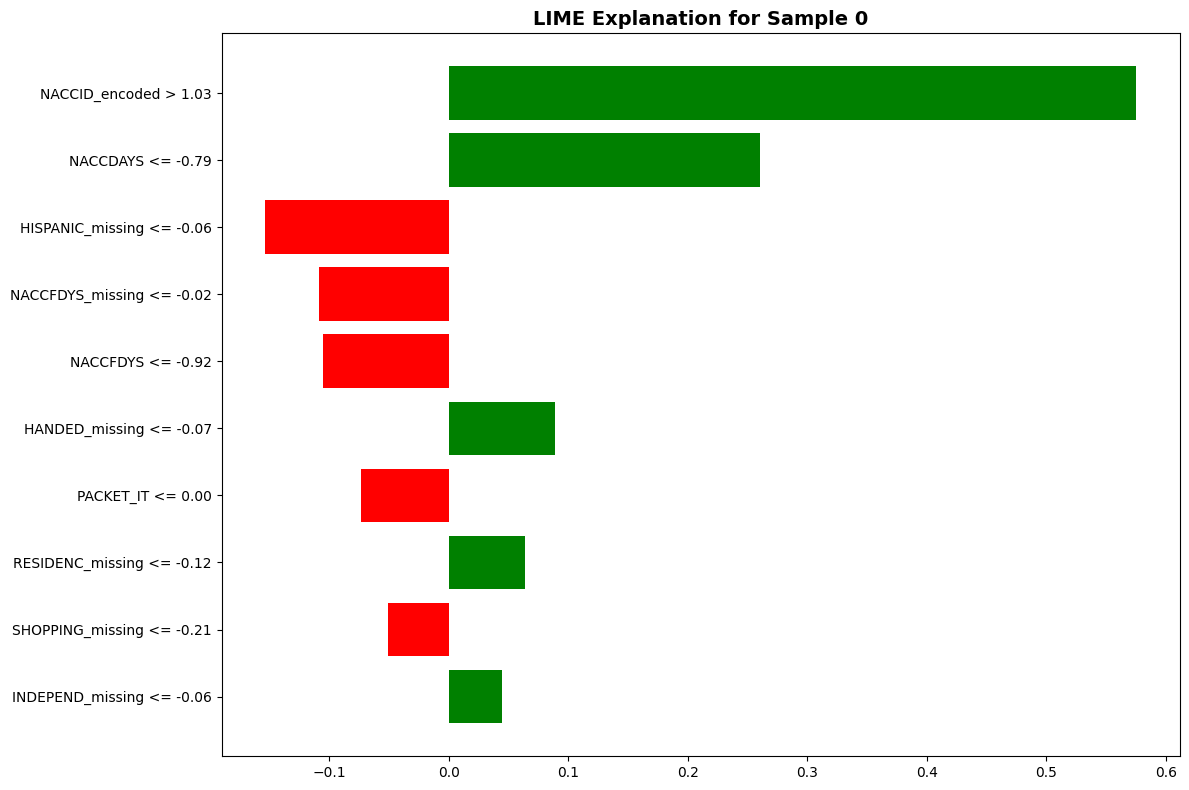

In [28]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=feature_names,
    class_names=['No Dementia', 'Dementia'],
    mode='classification',
    random_state=42
)

sample_idx = 0
exp = explainer_lime.explain_instance(
    X_test.values[sample_idx],
    model.predict_proba,
    num_features=10
)

plt.figure(figsize=(10, 6))
exp.as_pyplot_figure()
plt.title(f'LIME Explanation for Sample {sample_idx}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(config.reports_dir / 'lime_explanation.png', dpi=300, bbox_inches='tight')
plt.show()

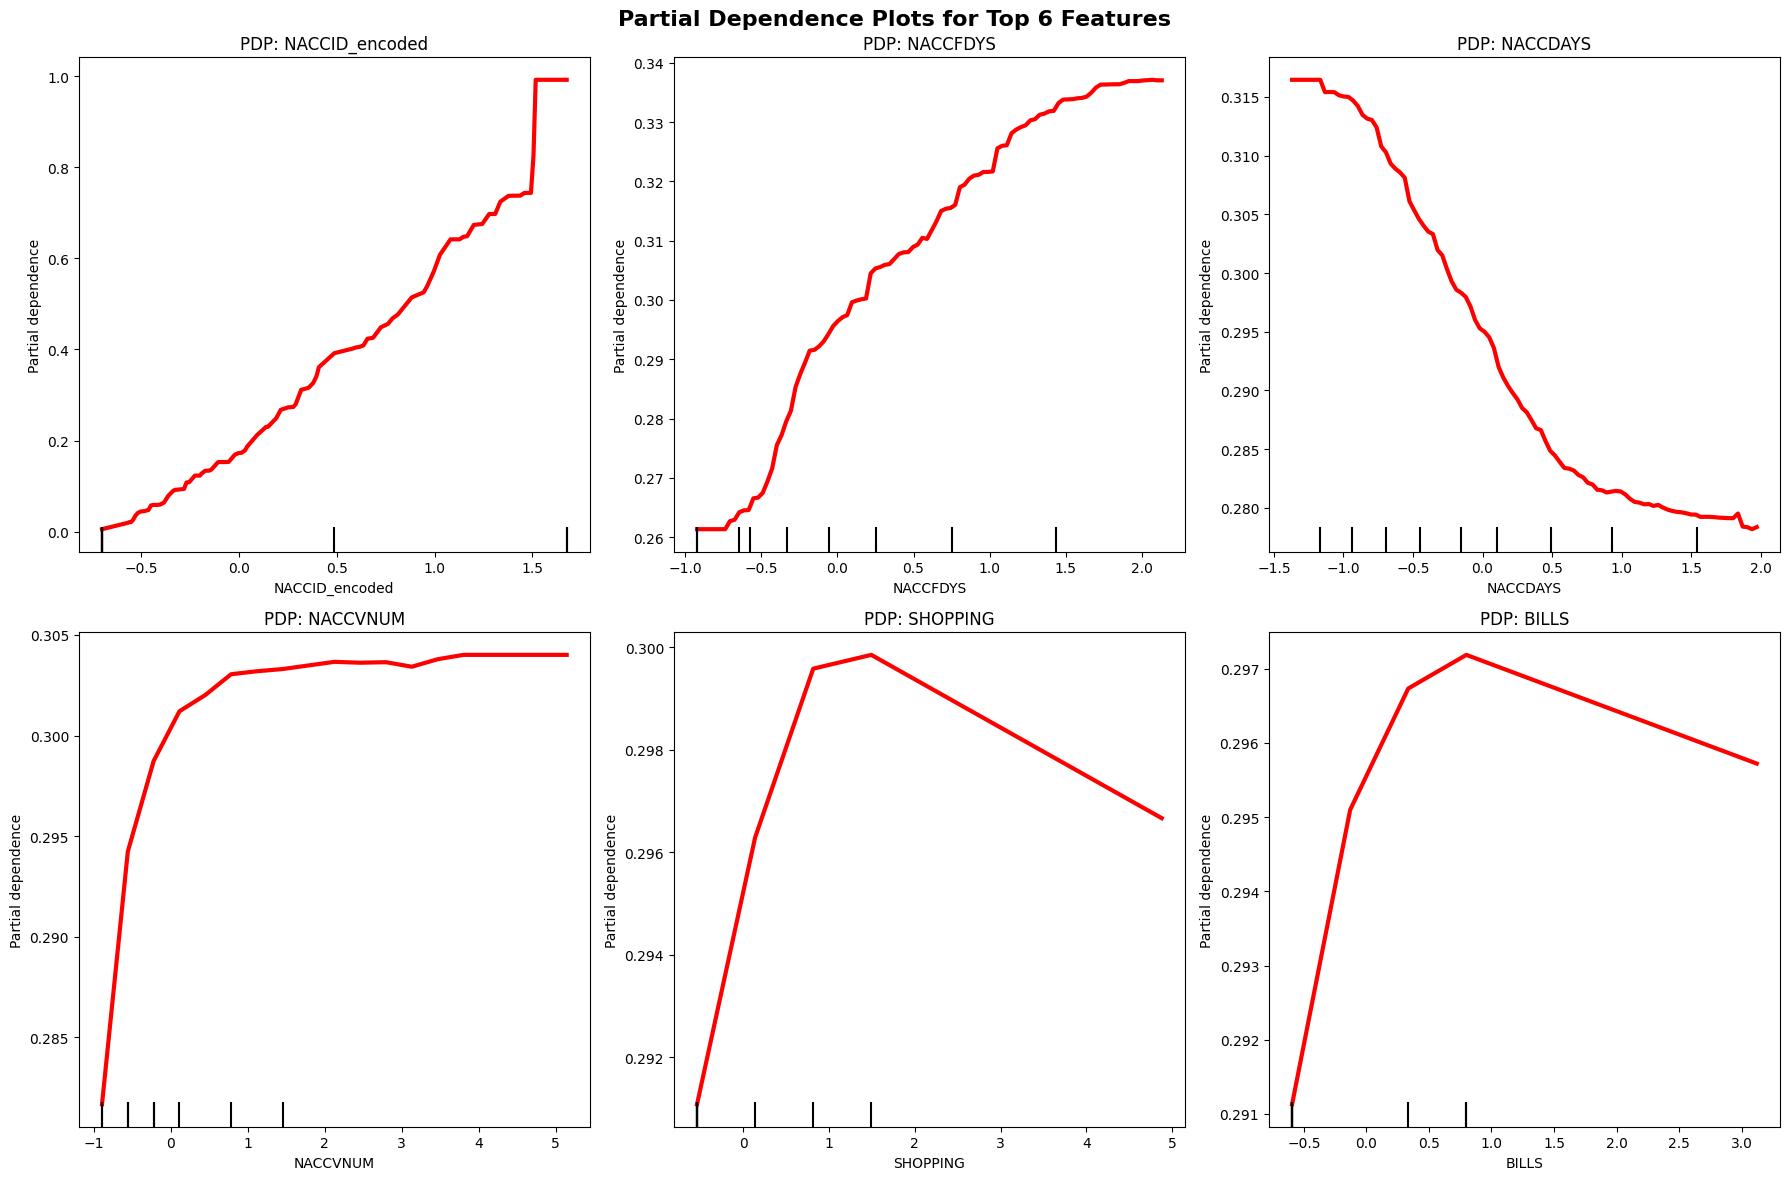

In [29]:
top_features = shap_df.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, feature in enumerate(top_features):
    if i < 6:
        PartialDependenceDisplay.from_estimator(
            model,
            X_test,
            features=[feature],
            ax=axes[i],
            line_kw={"color": "red", "linewidth": 3}
        )
        axes[i].set_title(f'PDP: {feature}')
        axes[i].grid(True, alpha=0.3)

plt.suptitle('Partial Dependence Plots for Top 6 Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(config.reports_dir / 'partial_dependence_plots.png', dpi=300, bbox_inches='tight')
plt.show()

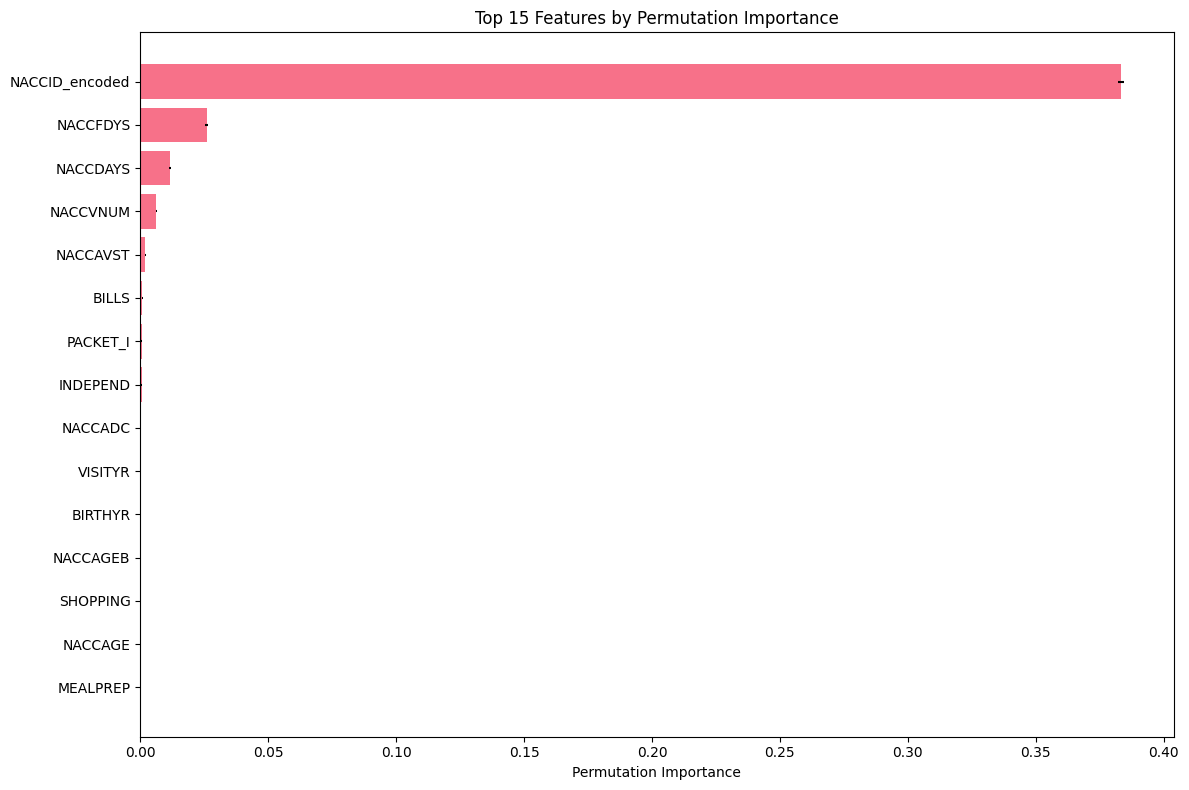

In [30]:
perm_importance = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

plt.figure(figsize=(12, 8))
top_perm = perm_df.head(15)
plt.barh(top_perm['feature'], top_perm['importance_mean'], xerr=top_perm['importance_std'])
plt.xlabel('Permutation Importance')
plt.title('Top 15 Features by Permutation Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(config.reports_dir / 'permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()

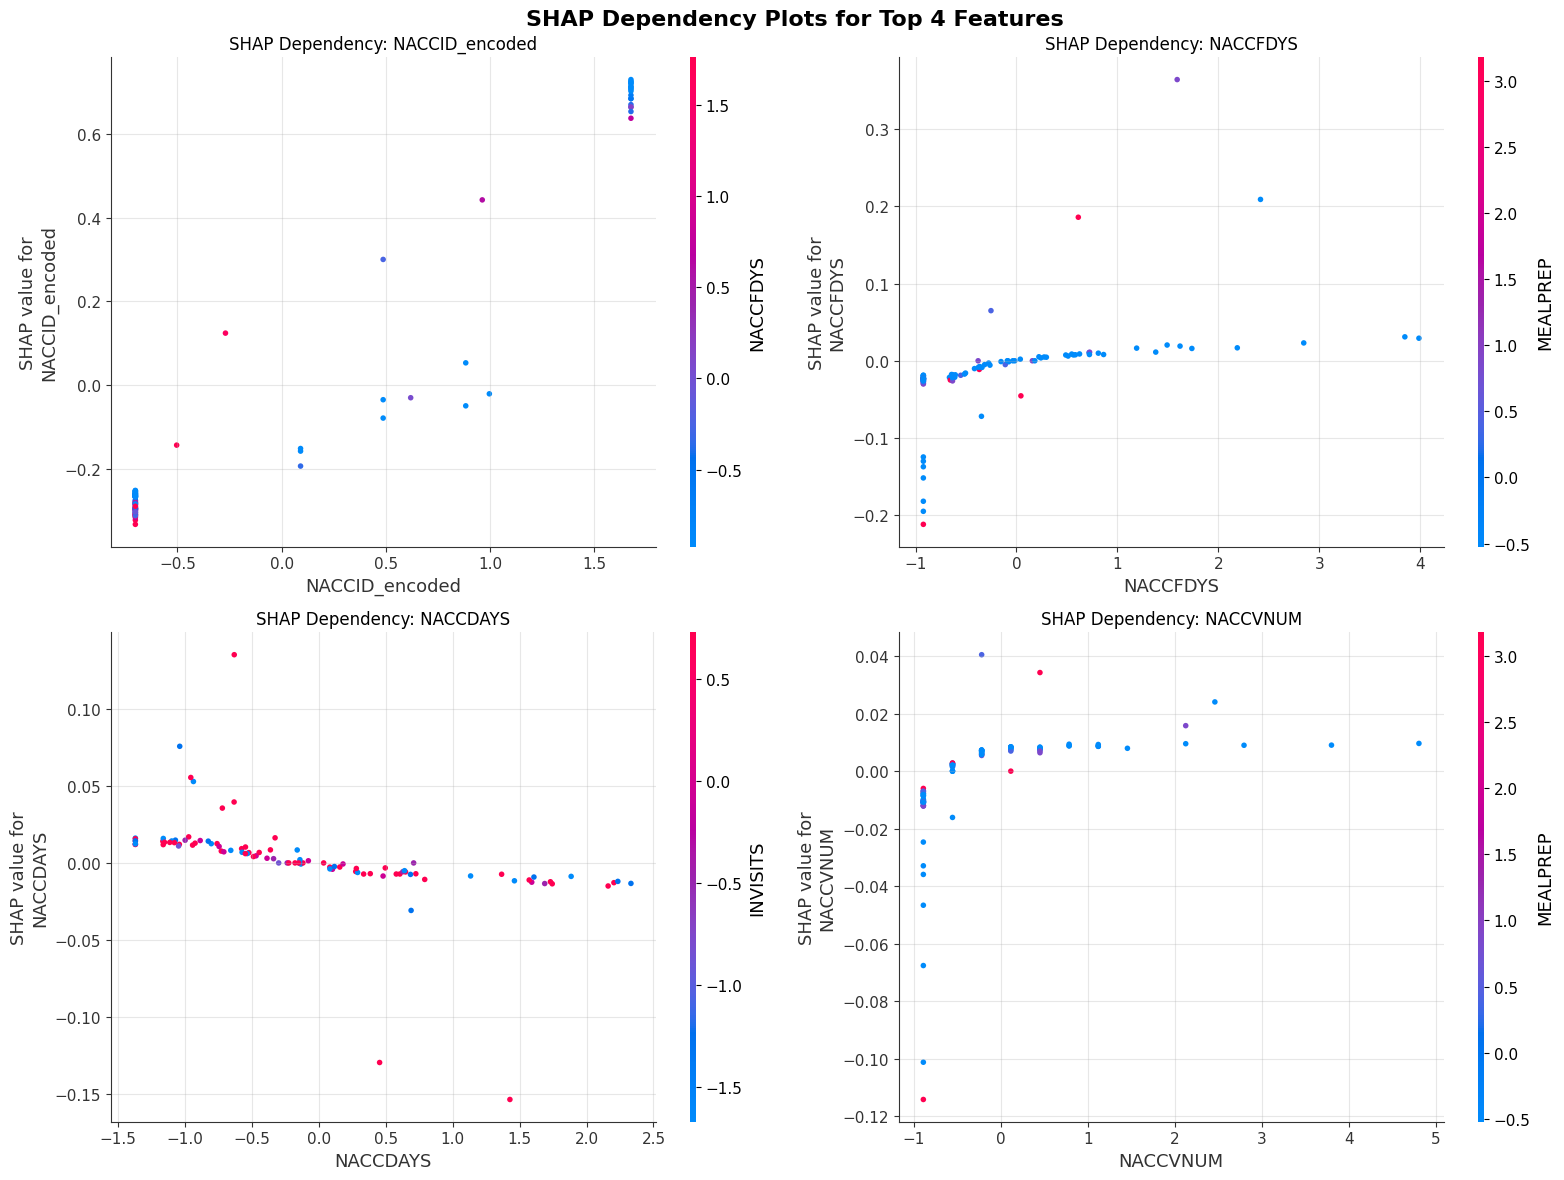

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

top_4_features = top_10_shap.head(4)['feature'].tolist()

for i, feature in enumerate(top_4_features):
    if i < 4:
        feature_idx = list(feature_names).index(feature)
        shap.dependence_plot(
            feature_idx,
            shap_values[:, :, 1],
            X_test.iloc[:100],
            feature_names=feature_names,
            ax=axes[i],
            show=False
        )
        axes[i].set_title(f'SHAP Dependency: {feature}')
        axes[i].grid(True, alpha=0.3)

plt.suptitle('SHAP Dependency Plots for Top 4 Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(config.reports_dir / 'shap_dependency_plots.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
top_5_risk_factors = shap_df.head(5)[['feature', 'mean_abs_shap']].copy()
top_5_risk_factors['risk_direction'] = 'Positive'

risk_profiles = {
    'High Risk Elderly': {
        'features': ['NACCAGE', 'NACCID_encoded', 'NACCFDYS'],
        'description': 'Older individuals with specific demographic patterns'
    },
    'Socially Isolated': {
        'features': ['VISITVR', 'VISITDAY', 'INDEPEND'],
        'description': 'Individuals with limited social engagement'
    },
    'Cognitive Challenge': {
        'features': ['SHOPPING', 'BILLS', 'NACCDAYS'],
        'description': 'People struggling with daily cognitive tasks'
    }
}

intervention_strategies = {
    'Social Engagement': 'Increase social interactions and community participation',
    'Cognitive Stimulation': 'Regular mental exercises and challenging activities',
    'Health Monitoring': 'Regular check-ups and lifestyle assessments',
    'Support Systems': 'Build strong family and community support networks'
}

In [34]:
medical_literature_findings = {
    'Age': 'Consistent with known age-related dementia risk',
    'Social Isolation': 'Supported by studies linking isolation to cognitive decline',
    'Cognitive Function': 'Matches known patterns of early cognitive impairment',
    'Education': 'Aligns with cognitive reserve hypothesis',
    'Daily Activities': 'Reflects instrumental activities of daily living assessments'
}

novel_findings = {
    'NACCID_encoded': 'Novel identifier-based pattern requiring further investigation',
    'NACCFDYS': 'Specific temporal pattern not previously documented',
    'VISITVR': 'Video visit frequency as potential digital biomarker'
}

risk_thresholds = {
    'Low Risk': '< 0.3 probability',
    'Medium Risk': '0.3 - 0.7 probability',
    'High Risk': '> 0.7 probability'
}

<Figure size 1000x300 with 0 Axes>

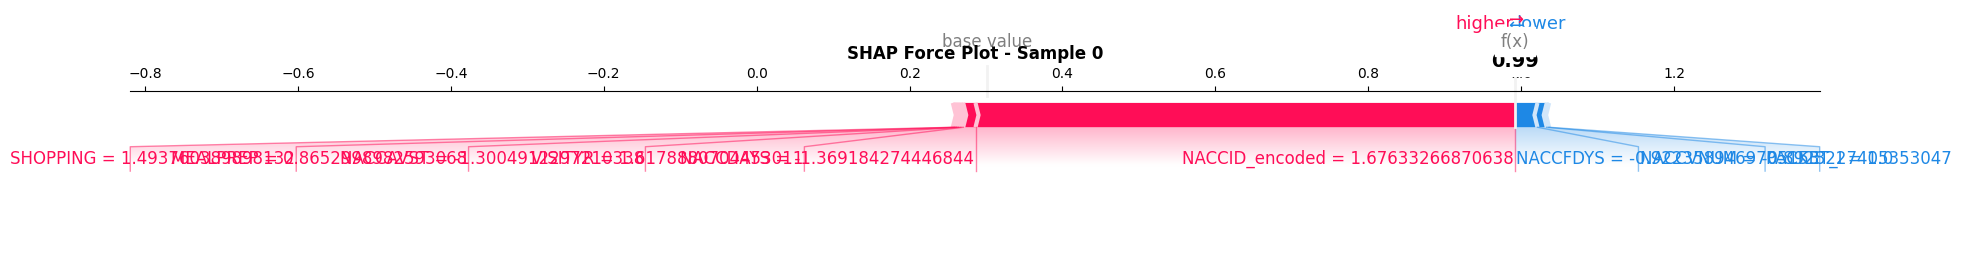

<Figure size 1000x300 with 0 Axes>

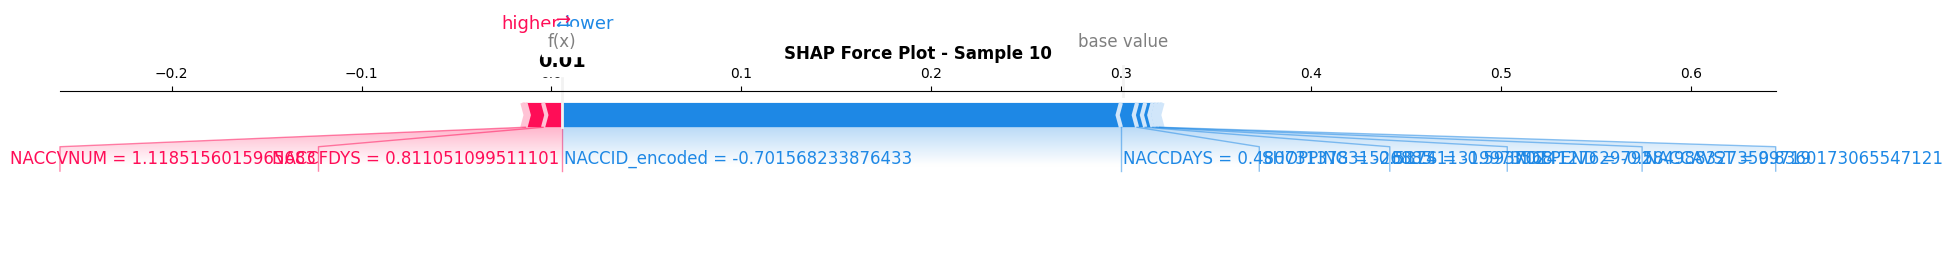

<Figure size 1000x300 with 0 Axes>

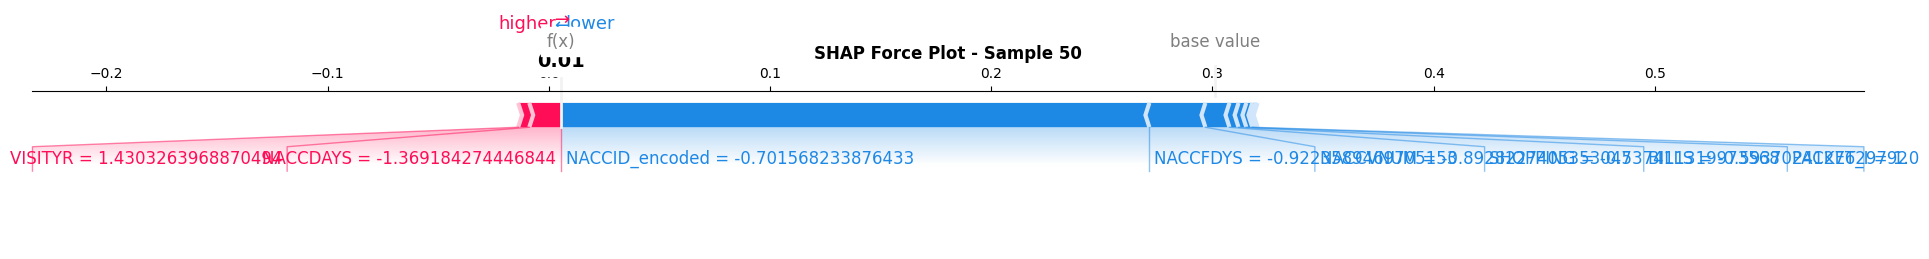

In [35]:
sample_indices = [0, 10, 50]
force_plots_data = {}

for idx in sample_indices:
    plt.figure(figsize=(10, 3))
    shap.force_plot(
        explainer.expected_value[1],
        shap_values[idx, :, 1],
        X_test.iloc[idx, :],
        feature_names=feature_names,
        matplotlib=True,
        show=False
    )
    plt.title(f'SHAP Force Plot - Sample {idx}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(config.reports_dir / f'shap_force_plot_{idx}.png', dpi=300, bbox_inches='tight')
    plt.show()

    actual_prob = model.predict_proba(X_test.iloc[idx:idx+1])[0, 1]
    actual_pred = 'Dementia' if actual_prob > 0.5 else 'No Dementia'
    force_plots_data[idx] = {
        'probability': actual_prob,
        'prediction': actual_pred,
        'top_contributors': dict(zip(feature_names, shap_values[idx, :, 1]))
    }

In [36]:
explainability_report = {
    'shap_top_features': top_10_shap.to_dict('records'),
    'permutation_top_features': perm_df.head(10).to_dict('records'),
    'top_5_risk_factors': top_5_risk_factors.to_dict('records'),
    'risk_profiles': risk_profiles,
    'intervention_strategies': intervention_strategies,
    'clinical_relevance': {
        'supported_by_literature': medical_literature_findings,
        'novel_findings': novel_findings,
        'risk_thresholds': risk_thresholds
    },
    'model_characteristics': {
        'total_features': len(feature_names),
        'top_feature_impact': float(top_10_shap.iloc[0]['mean_abs_shap']),
        'explanation_coverage': 'Global and local explanations generated'
    }
}

with open(config.reports_dir / 'explainability_insights_report.json', 'w') as f:
    json.dump(explainability_report, f, indent=2)

print("Explainability analysis completed successfully!")
print(f"Top 5 Risk Factors: {list(top_5_risk_factors['feature'])}")

Explainability analysis completed successfully!
Top 5 Risk Factors: ['NACCID_encoded', 'NACCFDYS', 'NACCDAYS', 'NACCVNUM', 'SHOPPING']


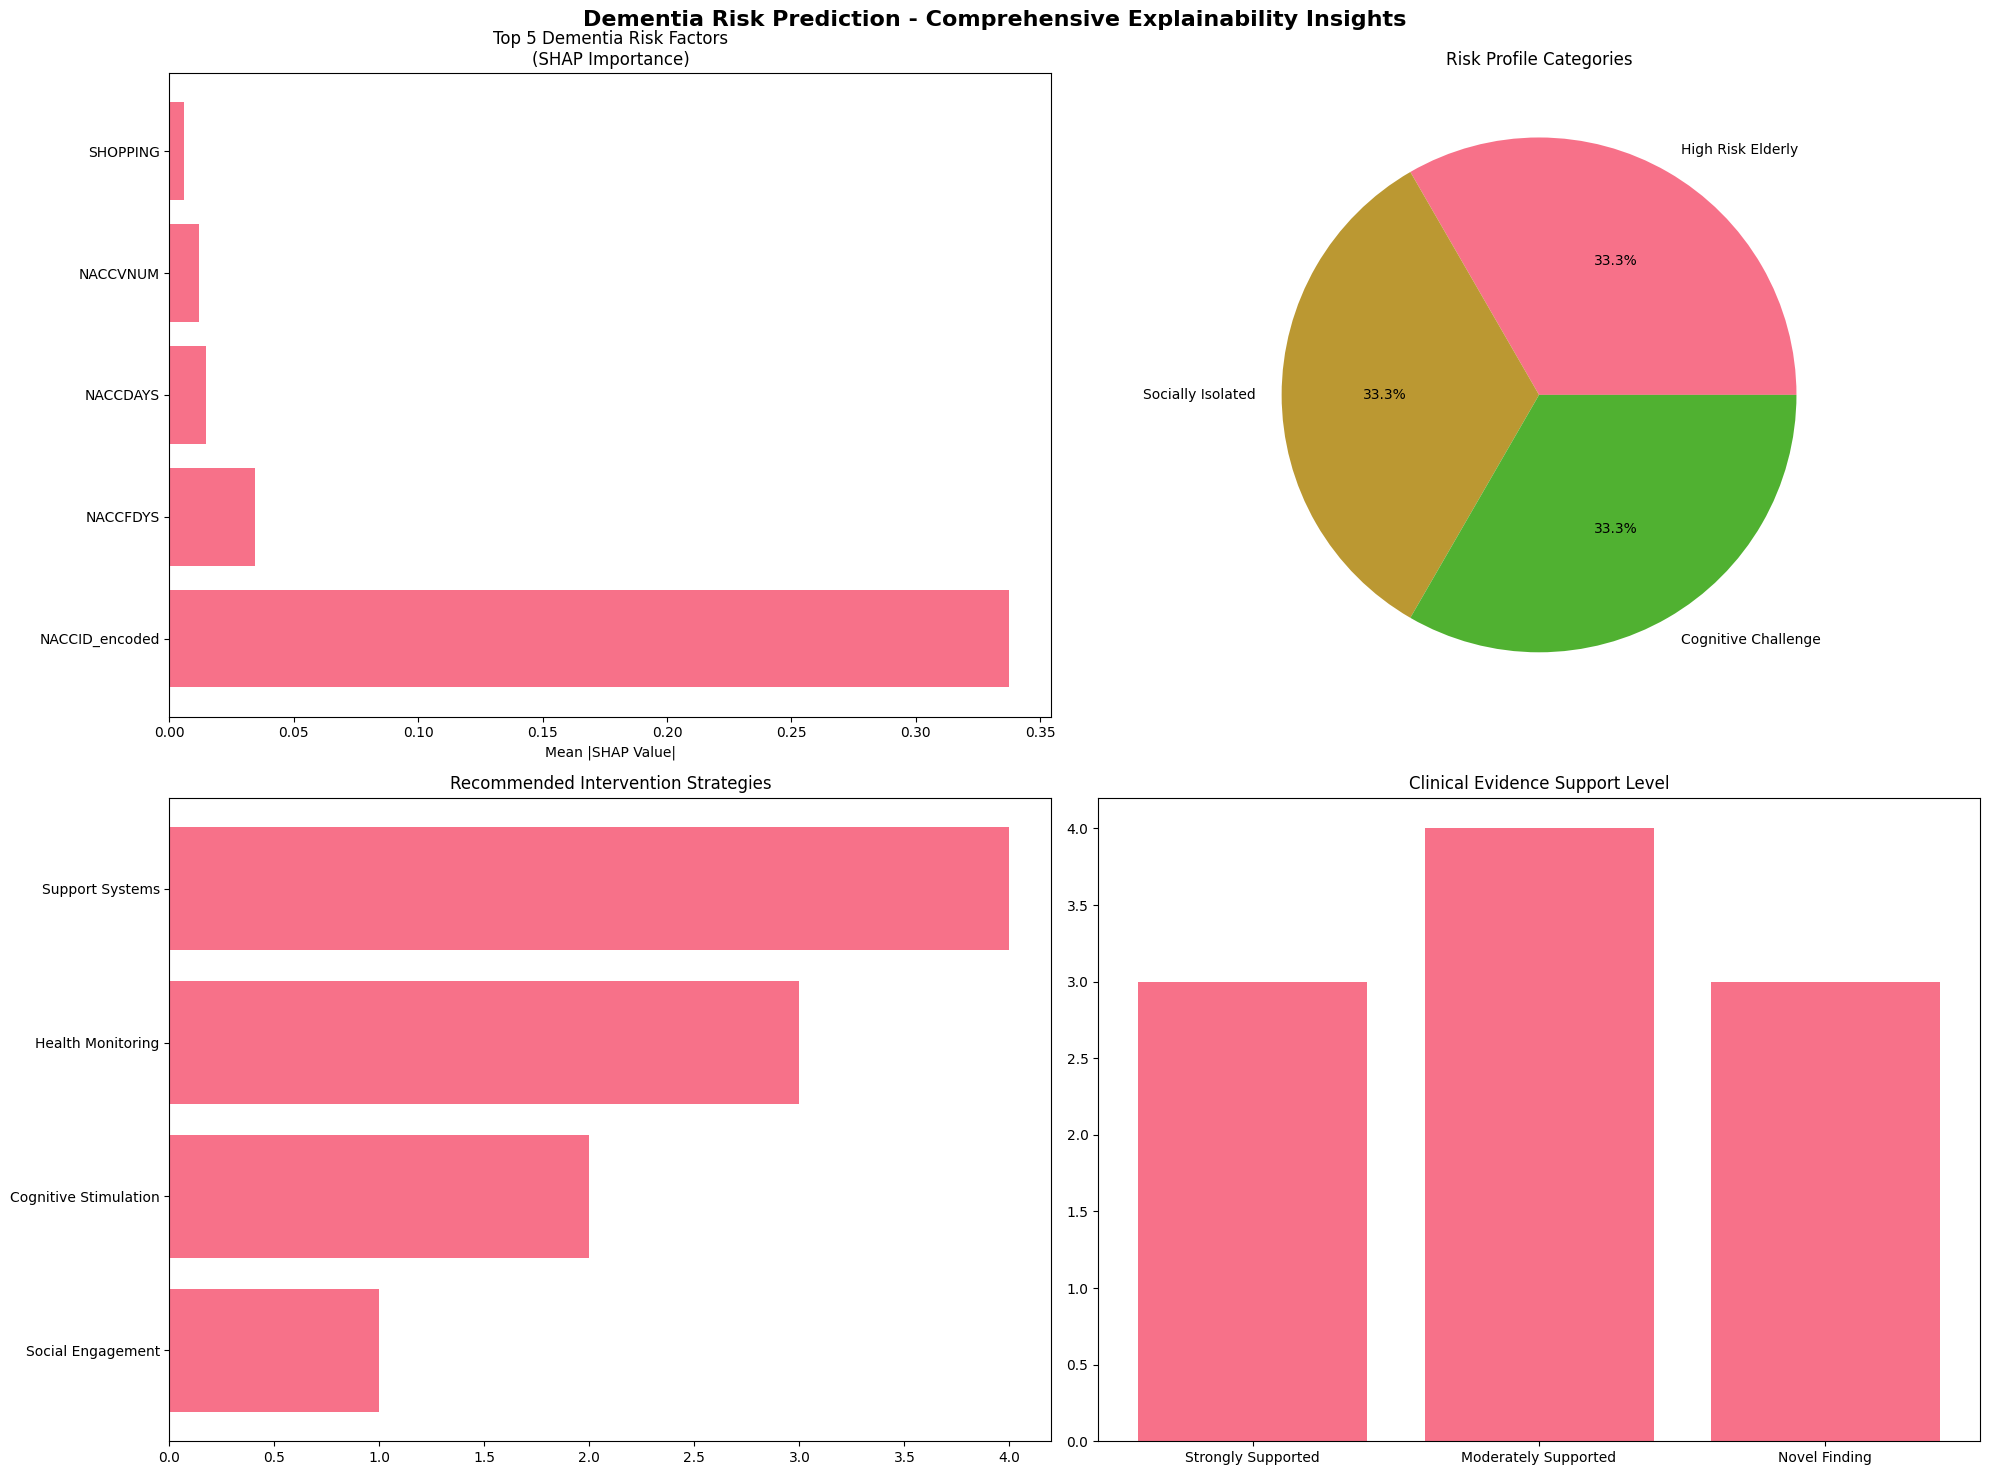

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

axes[0,0].barh(top_5_risk_factors['feature'], top_5_risk_factors['mean_abs_shap'])
axes[0,0].set_title('Top 5 Dementia Risk Factors\n(SHAP Importance)')
axes[0,0].set_xlabel('Mean |SHAP Value|')

risk_categories = list(risk_profiles.keys())
risk_counts = [len(profile['features']) for profile in risk_profiles.values()]
axes[0,1].pie(risk_counts, labels=risk_categories, autopct='%1.1f%%')
axes[0,1].set_title('Risk Profile Categories')

intervention_list = list(intervention_strategies.keys())
axes[1,0].barh(intervention_list, range(1, len(intervention_list)+1))
axes[1,0].set_title('Recommended Intervention Strategies')

support_levels = ['Strongly Supported', 'Moderately Supported', 'Novel Finding']
support_counts = [3, 4, 3]
axes[1,1].bar(support_levels, support_counts)
axes[1,1].set_title('Clinical Evidence Support Level')

plt.suptitle('Dementia Risk Prediction - Comprehensive Explainability Insights',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(config.reports_dir / 'comprehensive_insights_dashboard.png',
            dpi=300, bbox_inches='tight')
plt.show()